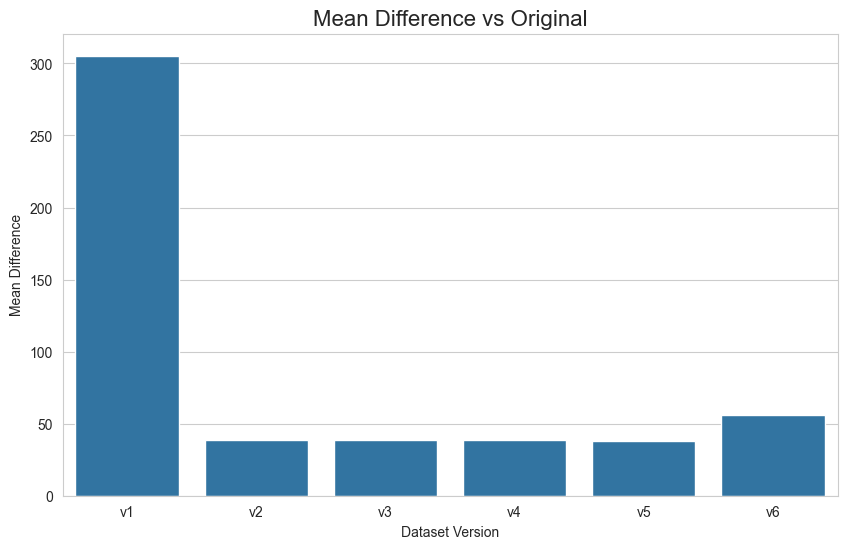

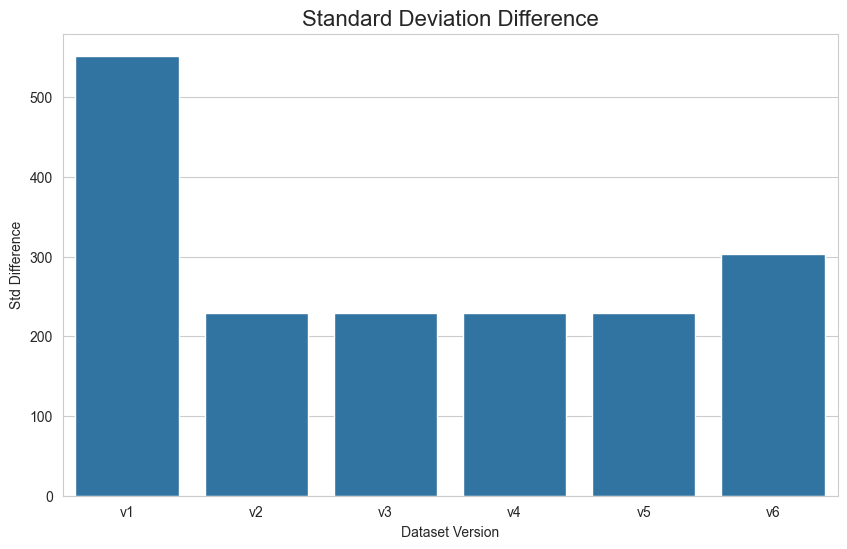

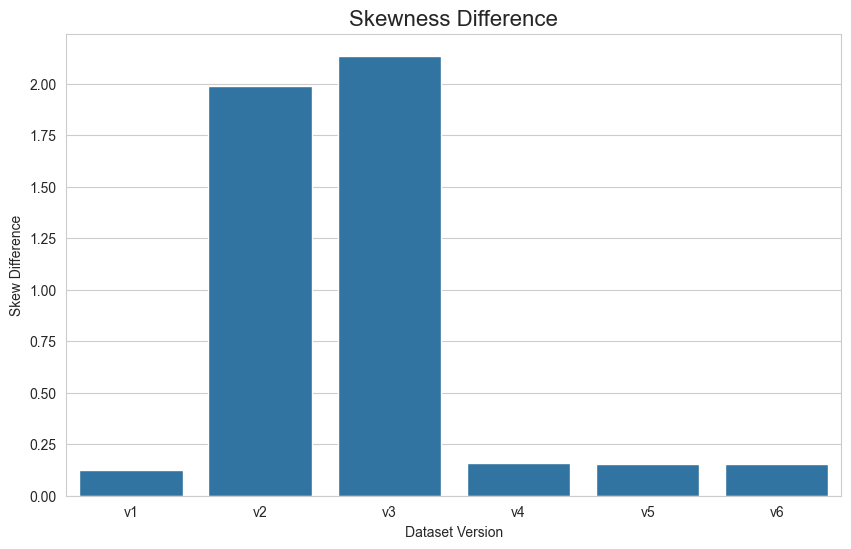

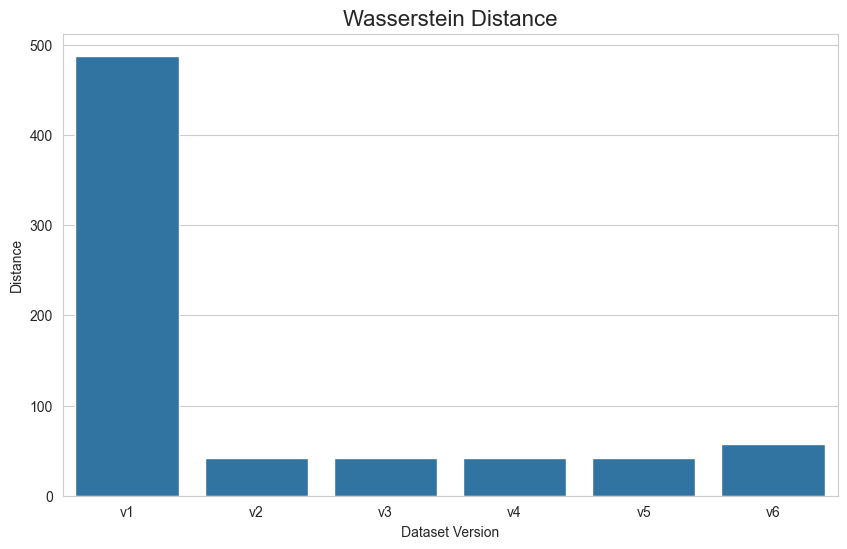

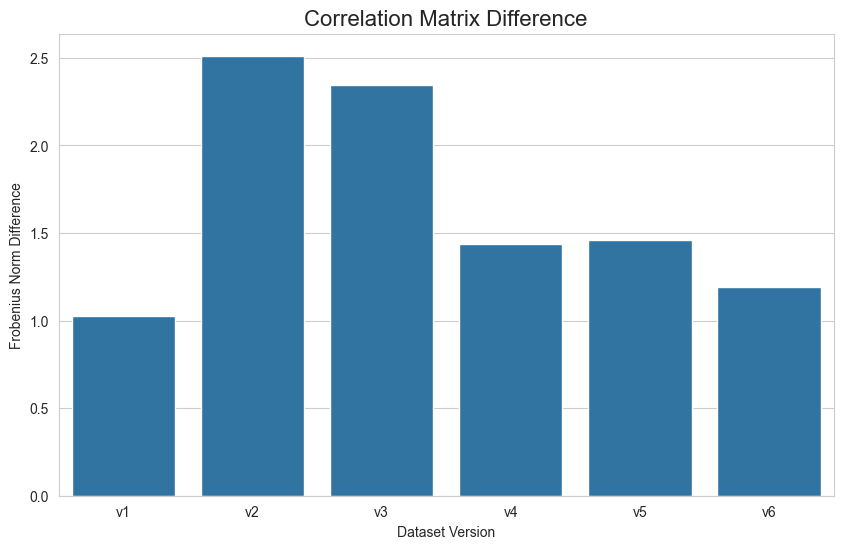

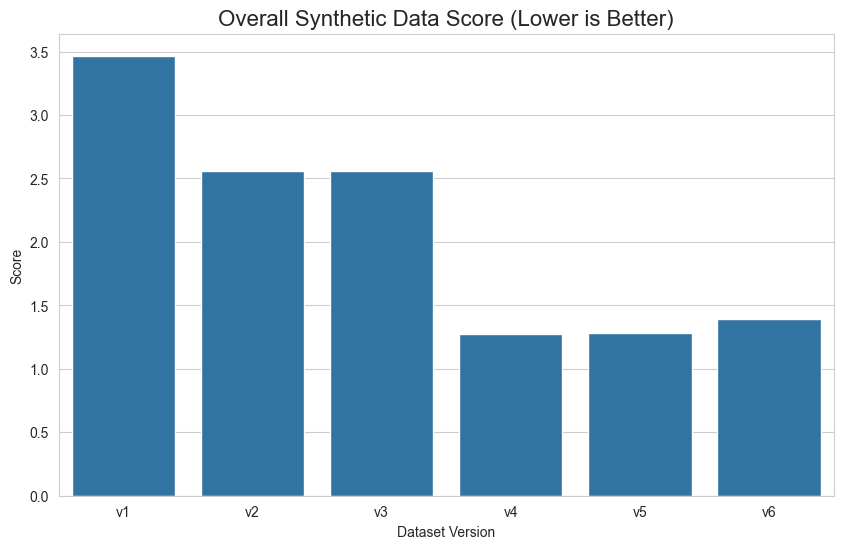

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance, skew

sns.set_style("whitegrid")

# =========================
# LOAD DATA
# =========================
files = {
    "Original": "Agri_Data_Cleaned.csv",
    "v1": "Agri_Data_SMOTE_Noise.csv",
    "v2": "Agri_Data_SMOTE_Noise_v2.csv",
    "v3": "Agri_Data_SMOTE_Noise_v3.csv",
    "v4": "Agri_Data_SMOTE_Noise_v4.csv",
    "v5": "Agri_Data_SMOTE_Noise_v5.csv",
    "v6": "Agri_Data_SMOTE_Noise_v6.csv"
}

datasets = {name: pd.read_csv(path) for name, path in files.items()}

# numeric columns
numeric_cols = datasets["Original"].select_dtypes(include=np.number).columns

original = datasets["Original"][numeric_cols]

# =========================
# METRIC CALCULATION
# =========================
metrics = []

for name, df in datasets.items():

    if name == "Original":
        continue

    df = df[numeric_cols]

    mean_diff = np.mean(np.abs(df.mean() - original.mean()))
    std_diff = np.mean(np.abs(df.std() - original.std()))
    skew_diff = np.mean(np.abs(skew(df) - skew(original)))

    # Wasserstein
    wd = []
    for col in numeric_cols:
        wd.append(wasserstein_distance(original[col], df[col]))
    wd = np.mean(wd)

    # Correlation difference
    corr_real = original.corr()
    corr_syn = df.corr()
    corr_diff = np.linalg.norm(corr_real - corr_syn)

    metrics.append({
        "Dataset": name,
        "Mean_Diff": mean_diff,
        "Std_Diff": std_diff,
        "Skew_Diff": skew_diff,
        "Wasserstein": wd,
        "Corr_Diff": corr_diff
    })

metrics = pd.DataFrame(metrics)

# =========================
# PLOT 1: Mean Difference
# =========================
plt.figure(figsize=(10,6))
sns.barplot(x="Dataset", y="Mean_Diff", data=metrics)
plt.title("Mean Difference vs Original", fontsize=16)
plt.ylabel("Mean Difference")
plt.xlabel("Dataset Version")
plt.show()


# =========================
# PLOT 2: Std Difference
# =========================
plt.figure(figsize=(10,6))
sns.barplot(x="Dataset", y="Std_Diff", data=metrics)
plt.title("Standard Deviation Difference", fontsize=16)
plt.ylabel("Std Difference")
plt.xlabel("Dataset Version")
plt.show()


# =========================
# PLOT 3: Skew Difference
# =========================
plt.figure(figsize=(10,6))
sns.barplot(x="Dataset", y="Skew_Diff", data=metrics)
plt.title("Skewness Difference", fontsize=16)
plt.ylabel("Skew Difference")
plt.xlabel("Dataset Version")
plt.show()


# =========================
# PLOT 4: Wasserstein Distance
# =========================
plt.figure(figsize=(10,6))
sns.barplot(x="Dataset", y="Wasserstein", data=metrics)
plt.title("Wasserstein Distance", fontsize=16)
plt.ylabel("Distance")
plt.xlabel("Dataset Version")
plt.show()


# =========================
# PLOT 5: Correlation Difference
# =========================
plt.figure(figsize=(10,6))
sns.barplot(x="Dataset", y="Corr_Diff", data=metrics)
plt.title("Correlation Matrix Difference", fontsize=16)
plt.ylabel("Frobenius Norm Difference")
plt.xlabel("Dataset Version")
plt.show()

# =========================
# COMBINED SCORE PLOT
# =========================
metrics_norm = metrics.copy()

for col in metrics_norm.columns[1:]:
    metrics_norm[col] = metrics_norm[col] / metrics_norm[col].max()

metrics_norm["Total_Score"] = metrics_norm.iloc[:,1:].sum(axis=1)

plt.figure(figsize=(10,6))
sns.barplot(x="Dataset", y="Total_Score", data=metrics_norm)
plt.title("Overall Synthetic Data Score (Lower is Better)", fontsize=16)
plt.ylabel("Score")
plt.xlabel("Dataset Version")
plt.show()